### Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.under_sampling import RandomUnderSampler
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
from torch.utils.data import Dataset
from transformers import Trainer
from transformers import TrainingArguments
from transformers import DataCollatorWithPadding
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

C:\Users\-\PycharmProjects\RU_reviews_sentiment_analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Датасет

In [2]:
df = pd.read_csv('sentiment_dataset.csv')

### Добыча токенизаторов и BERT моделей

In [3]:
classes = ["negative", "neutral", "positive"]

id2class = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

class2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

DEBERTA_MODEL_PATH = "deepvk/deberta-v1-base"

deberta_tokenizer = AutoTokenizer.from_pretrained(
    DEBERTA_MODEL_PATH,
    token=token
)

deberta_model = AutoModelForSequenceClassification.from_pretrained(
    DEBERTA_MODEL_PATH,
    num_labels=len(classes),
    id2label=id2class,
    label2id=class2id,
    token=token,

    # Для sentiment classification нужна multi_class,
    # а НЕ multi_label
    problem_type="single_label_classification"
)

print("DeBERTa loaded successfully")



RUBERT_MODEL_PATH = "DeepPavlov/rubert-base-cased"

rubert_tokenizer = AutoTokenizer.from_pretrained(
    RUBERT_MODEL_PATH,
    token=token
)

rubert_model = AutoModelForSequenceClassification.from_pretrained(
    RUBERT_MODEL_PATH,
    num_labels=len(classes),
    id2label=id2class,
    label2id=class2id,
    token=token,
    problem_type="single_label_classification"
)

print("RuBERT loaded successfully")

Loading weights: 100%|██████████| 160/160 [00:00<00:00, 10667.10it/s]
[transformers] DebertaForSequenceClassification LOAD REPORT from: deepvk/deberta-v1-base
Key                 | Status  | 
--------------------+---------+-
classifier.bias     | MISSING | 
classifier.weight   | MISSING | 
pooler.dense.weight | MISSING | 
pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DeBERTa loaded successfully


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 28400.64it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/a

RuBERT loaded successfully


### EDA

###### Вывод информации

In [4]:
df.info()
# Пропусков нет

<class 'pandas.DataFrame'>
RangeIndex: 290458 entries, 0 to 290457
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   text    290458 non-null  str  
 1   label   290458 non-null  int64
 2   src     290458 non-null  str  
dtypes: int64(1), str(2)
memory usage: 6.6 MB


###### Проверка баланса классов

In [5]:
df['label'].value_counts()
# 0: Neutral
# 1: Positive
# 2: Negative

label
2    96992
1    96877
0    96589
Name: count, dtype: int64

###### Изучение длин текста

In [6]:
texts_lengths = df['text'].str.len()

In [7]:
minimum_len = min(texts_lengths)
maximum_len = max(texts_lengths)
median_len = np.median(texts_lengths)
average_len = np.average(texts_lengths)
percentile_95 = np.percentile(texts_lengths, 95)
percentile_90 = np.percentile(texts_lengths, 90)

In [8]:
print(f'Минимальна длина отзыва: {minimum_len}\n'
      f'Максимальная длина отзыва: {maximum_len}\n'
      f'Медианная длина отзыва: {median_len}\n'
      f'Средне статистическая длина отзывов: {average_len}\n'
      f'Персентиль 95: {percentile_95}\n'
      f'Персентиль 90: {percentile_90}\n')

Минимальна длина отзыва: 1
Максимальная длина отзыва: 1500
Медианная длина отзыва: 175.0
Средне статистическая длина отзывов: 339.865102699874
Персентиль 95: 1202.0
Персентиль 90: 964.0



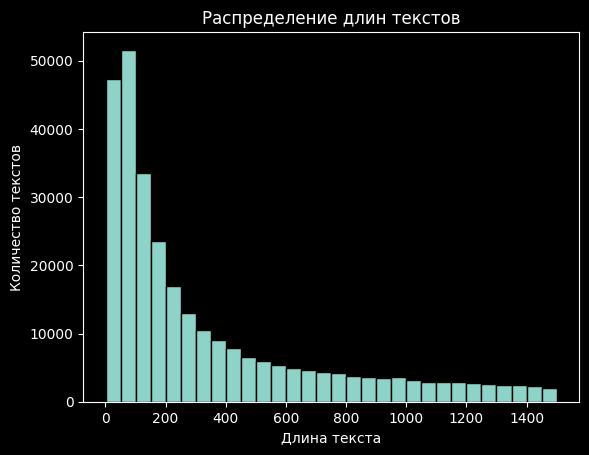

In [9]:
plt.hist(x=texts_lengths, bins=30, edgecolor='black')
plt.xlabel("Длина текста")
plt.ylabel("Количество текстов")
plt.title("Распределение длин текстов")
plt.show()

# Не нормальное распределение
# Текста длинной 50-100 доминируют

### Обработка датасета

###### Удаление лишних стобцов

In [10]:
x, y = pd.DataFrame(data=df['text']), pd.DataFrame(data=df['label'])

###### Баансировка классов

In [11]:
strategy = {0: 5000, 1: 5000, 2: 5000}
rus = RandomUnderSampler(sampling_strategy=strategy, random_state=42)
x, y = rus.fit_resample(x, y)

###### Обработка текста

In [12]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [13]:
x['text'] = x['text'].apply(clean_text)

### Split

###### Разделение на обучающую, тестовую и валидационную выборку

In [14]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    x['text'],
    y['label'],
    test_size=0.3,
    stratify=y['label'],
    random_state=42
)

In [15]:
mid = len(test_texts) // 2

In [16]:
test_texts, validation_texts = test_texts.iloc[:mid], test_texts.iloc[mid:]
test_labels, validation_labels = test_labels.iloc[:mid], test_labels.iloc[mid:]

###### Проверка размерностей

In [17]:
print(f'Размерность train texts: {train_texts.shape}\n'
      f'Размерность train labels: {train_labels.shape}\n'
      f'Размерность validation texts: {validation_texts.shape}\n'
      f'Размерность validation labels: {validation_labels.shape}\n'
      f'Размерность test texts: {test_texts.shape}\n'
      f'Размерность test labels: {test_labels.shape}')

Размерность train texts: (10500,)
Размерность train labels: (10500,)
Размерность validation texts: (2250,)
Размерность validation labels: (2250,)
Размерность test texts: (2250,)
Размерность test labels: (2250,)


### Baseline model

###### Токенизация

In [18]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=10
)

In [19]:
X_train_tfidf = vectorizer.fit_transform(train_texts)
X_test_tfidf = vectorizer.transform(test_texts)

###### Обучение модели

In [20]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

In [21]:
model.fit(X_train_tfidf, train_labels)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

###### Оценка качастве

In [22]:
y_pred = model.predict(X_test_tfidf)

In [23]:
print("Accuracy:", accuracy_score(test_labels, y_pred))
print(classification_report(test_labels, y_pred))

Accuracy: 0.6577777777777778
              precision    recall  f1-score   support

           0       0.57      0.57      0.57       754
           1       0.76      0.75      0.75       751
           2       0.65      0.66      0.65       745

    accuracy                           0.66      2250
   macro avg       0.66      0.66      0.66      2250
weighted avg       0.66      0.66      0.66      2250



### BERT model's configurations

###### Функция оценки качества

In [24]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

###### Датасет

In [25]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length
        )

        enc["labels"] = label
        return enc

###### Обучающие параметры

In [26]:
training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    num_train_epochs=3,
    weight_decay=0.01,

    logging_steps=50,
    report_to="none",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    fp16=True
)

###### Функция обучения модели

In [27]:
def train_model(model, tokenizer, data_collator, X_train, y_train, X_test, y_test):

    train_dataset = TextDataset(X_train, y_train, tokenizer)
    test_dataset = TextDataset(X_test, y_test, tokenizer)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    trainer.train()

    results = trainer.evaluate()

    return trainer, results

### DeBERTa

In [28]:
data_collator = DataCollatorWithPadding(tokenizer=deberta_tokenizer)

deberta_trainer, deberta_results = train_model(
    deberta_model,
    deberta_tokenizer,
    data_collator,
    train_texts,
    train_labels,
    test_texts,
    test_labels,
)

print("DeBERTa results:")
print(deberta_results)

C:\Users\-\PycharmProjects\RU_reviews_sentiment_analysis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.628667,0.638315,0.713333,0.713246
2,0.595599,0.642036,0.717333,0.715029
3,0.515572,0.649552,0.723556,0.723741


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.51it/s]
C:\Users\-\PycharmProjects\RU_reviews_sentiment_analysis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.76it/s]
C:\Users\-\PycharmProjects\RU_reviews_sentiment_analysis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.79it/s]
C:\Users\-\PycharmProjects\RU_reviews_sentiment_analysis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.515572,0.649552,3,0.723556,0.723741


DeBERTa results:
{'eval_loss': 0.6495524048805237, 'eval_accuracy': 0.7235555555555555, 'eval_f1_macro': 0.7237406442570394}


### RuBERT

In [29]:
data_collator = DataCollatorWithPadding(tokenizer=rubert_tokenizer)

rubert_trainer, rubert_results = train_model(
    rubert_model,
    rubert_tokenizer,
    data_collator,
    train_texts,
    train_labels,
    test_texts,
    test_labels
)

print("RuBERT results:")
print(deberta_results)

C:\Users\-\PycharmProjects\RU_reviews_sentiment_analysis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.671066,0.722639,0.674222,0.679486
2,0.602019,0.702584,0.688444,0.690139
3,0.448227,0.735000,0.701333,0.703122


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.64it/s]
C:\Users\-\PycharmProjects\RU_reviews_sentiment_analysis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.70it/s]
C:\Users\-\PycharmProjects\RU_reviews_sentiment_analysis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.50it/s]
C:\Users\-\PycharmProjects\RU_reviews_sentiment_analysis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.448227,0.735000,3,0.701333,0.703122


RuBERT results:
{'eval_loss': 0.6495524048805237, 'eval_accuracy': 0.7235555555555555, 'eval_f1_macro': 0.7237406442570394}


### Сравнение

In [30]:
print("\n=== Сравнение ===")

print("DeBERTa:")
print(deberta_results)

print("\nRuBERT:")
print(rubert_results)


=== Сравнение ===
DeBERTa:
{'eval_loss': 0.6495524048805237, 'eval_accuracy': 0.7235555555555555, 'eval_f1_macro': 0.7237406442570394}

RuBERT:
{'eval_loss': 0.7350001335144043, 'eval_accuracy': 0.7013333333333334, 'eval_f1_macro': 0.7031217677690299}
